In [2]:
import constants
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
nee_msa_mean = pd.read_csv(constants.NEE_MSA_MONTHLY_MEAN)
msa_region_name = pd.read_csv(constants.MSA_NAME_REGION_TABLE)

In [10]:
nee_msa_mean.columns

Index(['NAMELSAD', 'nee_mean_200101', 'nee_mean_200102', 'nee_mean_200103',
       'nee_mean_200104', 'nee_mean_200105', 'nee_mean_200106',
       'nee_mean_200107', 'nee_mean_200108', 'nee_mean_200109',
       ...
       'nee_mean_201503', 'nee_mean_201504', 'nee_mean_201505',
       'nee_mean_201506', 'nee_mean_201507', 'nee_mean_201508',
       'nee_mean_201509', 'nee_mean_201510', 'nee_mean_201511',
       'nee_mean_201512'],
      dtype='object', length=181)

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_34120\1641234390.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Regions", bbox_to_anchor=(1.05, 1), loc='upper left')


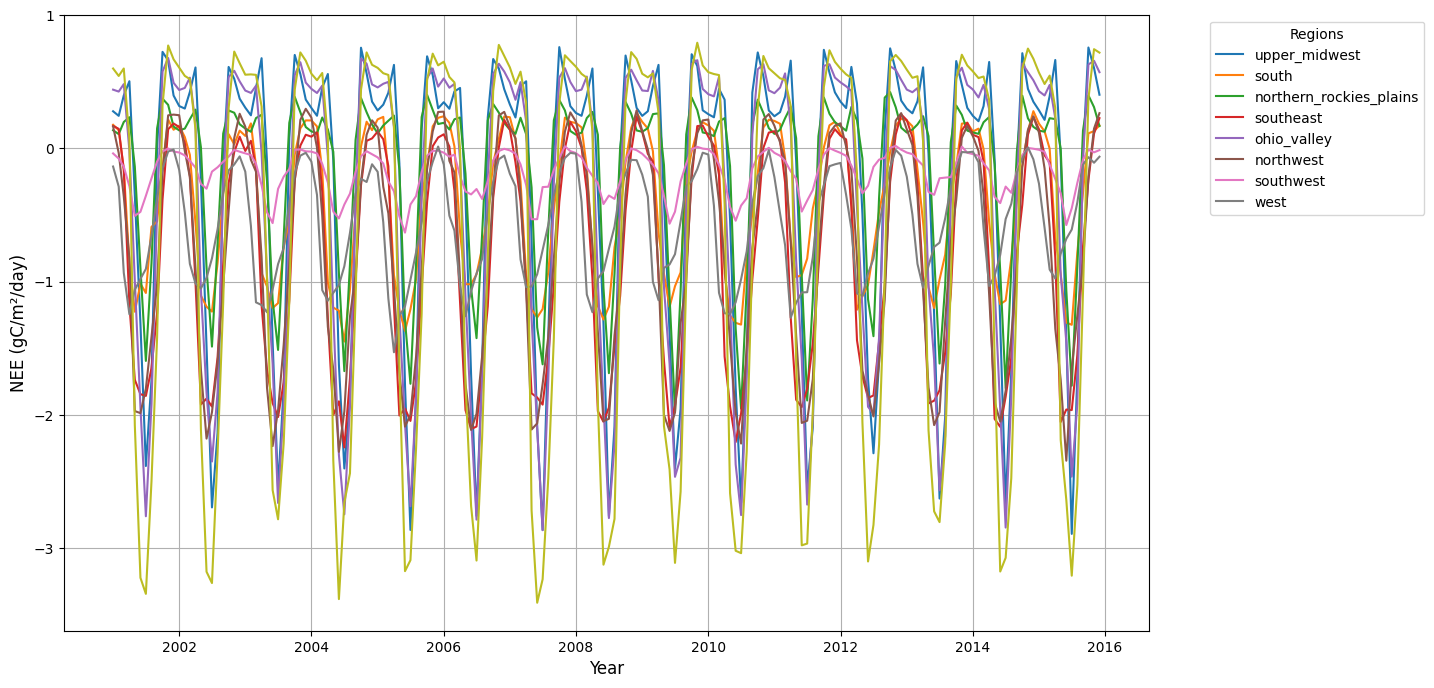

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Reshape the NEE data from wide to long format
nee_long_df = pd.melt(nee_msa_mean, id_vars=['NAMELSAD'], var_name='Month', value_name='NEE')

# Extract year and month from the 'Month' column for better handling
nee_long_df['Year'] = nee_long_df['Month'].str[9:13].astype(int)
nee_long_df['Month'] = nee_long_df['Month'].str[13:15].astype(int)
nee_long_df['Month_Date'] = pd.to_datetime(nee_long_df['Year'].astype(str) + nee_long_df['Month'].astype(str).str.zfill(2), format='%Y%m')

# Merge with the region data
merged_df = pd.merge(nee_long_df, msa_region_name, on='NAMELSAD')

# Set up the plot
plt.figure(figsize=(14, 8))

# Loop through each region and plot the monthly NEE trends for MSAs in that region
for region in merged_df['region'].unique():
    region_data = merged_df[merged_df['region'] == region]
    
    # Group by month and calculate the mean NEE for each month across all MSAs in the region
    region_monthly_mean = region_data.groupby('Month_Date')['NEE'].mean()

    plt.xlabel('Year', fontsize=12)
    plt.ylabel('NEE (gC/m²/day)', fontsize=12)
    plt.grid(True)
    plt.legend(title="Regions", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Plot the trend for the region (averaged NEE for all MSAs in the region)
    plt.plot(region_monthly_mean.index, region_monthly_mean.values, label=region)


In [6]:
msa_region_name.columns

Index(['NAMELSAD', 'region'], dtype='object')